# Demo for the ProblemsSolvers class.

This script is intended to help with debugging problems and solvers.

It create problem-solver groups (using the directory) and runs multiple macroreplications of each problem-solver pair.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [1]:
import sys
from pathlib import Path

import random 
import numpy as np 

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [2]:
# Specify the names of the solver(s) and problem(s) to test.
solver_abbr_names = ["ASTRODF", "ASTROMORF"] #add NELDMD once fixed

problem_abbr_names =  ["DYNAMNEWS-1"]
num_macroreps = 5
num_postreps = 50  
num_postreps_init_opt = 50

In [5]:
from simopt.experiment_base import ProblemSolver
def populate_experiments(problems, solvers):
    # Create a list of list of ProblemSolvers to be passed through the ProblemsSolvers constructor 
    problem_solvers = []
    for solver in solvers : 
        solvers_ps = []
        if solver.name == 'ASTROMORF' :
            solver_rename = f'ASTROMORF_dim{solver.factors["initial subspace dimension"]}'
        else : 
            solver_rename = solver.name
        for problem in problems :
            solvers_ps.append(ProblemSolver(problem=problem, solver=solver, solver_rename=solver_rename))
        problem_solvers.append(solvers_ps)

    return problem_solvers

In [6]:

from simopt.experiment_base import instantiate_problem, instantiate_solver
from simopt.solvers.astromorf import PolyBasisType
#Create Solver and Problem instances
budget = 10000 
subspace_dim = 3
new_dim = 30 

#! NEED TO UPDATE - EVERYTHING BUT NETWORK-1
ASTROMoRF_subspace_degree: dict = {
    'DYNAMNEWS-1': {'initial subspace dimension': 7, 'polynomial degree': 4},
    'NETWORK-1': {'initial subspace dimension': 7, 'polynomial degree': 4},
    'FACSIZE-1': {'initial subspace dimension': 1, 'polynomial degree': 1},
    'CONTAM-2': {'initial subspace dimension': 5, 'polynomial degree': 4},
    'ROSENBROCK-1': {'initial subspace dimension': 3, 'polynomial degree': 5},
}

problem_solvers = [[ProblemSolver(problem_name=problem, solver_name=solver, problem_fixed_factors={'budget': 1000}) for problem in problem_abbr_names] for idx, solver in enumerate(solver_abbr_names)]


for ps in problem_solvers : 
    for p in ps : 
        if p.solver.name == 'ASTROMoRF' :
            #update the initial subspace dimension and polynomial degree based on problem
            new_factors = ASTROMoRF_subspace_degree[p.problem.name]
            p.solver.factors.update(new_factors)
        print(p.solver.name, p.problem.name)


ASTRODF DYNAMNEWS-1
ASTROMORF DYNAMNEWS-1


In [7]:
# Initialize an instance \of the experiment class.
from simopt.experiment_base import ProblemsSolvers

mymetaexperiment = ProblemsSolvers(experiments=problem_solvers, file_name_path='poly_bases_test.pickle')


for experiment in mymetaexperiment.experiments : 
    print(f'SOLVER: {experiment[0].solver.name}')
    for ps in experiment :
        print(f'Running experiment: Problem = {ps.problem.name}, Solver = {ps.solver.name}')
    

# Write to log file. 
mymetaexperiment.log_group_experiment_results()

SOLVER: ASTRODF
Running experiment: Problem = DYNAMNEWS-1, Solver = ASTRODF
SOLVER: ASTROMORF
Running experiment: Problem = DYNAMNEWS-1, Solver = ASTROMORF


In [8]:
# Run a fixed number of macroreplications of each solver on each problem.
mymetaexperiment.run(n_macroreps=num_macroreps)

ASTROMoRF solver finalising...
ASTROMoRF solver finalising...

✓ ASTROMoRF Solver completed. Diagnostics written to: /Users/benjaminrees/Desktop/simopt/Diagnostics/ASTROMORF_on_DYNAMNEWS-1/astromorf_diagnostics_DYNAMNEWS-1_2025-11-24_03-56-50_pid21103_r6537.txt
ASTROMoRF solver finalising...
ASTROMoRF solver finalising...

✓ ASTROMoRF Solver completed. Diagnostics written to: /Users/benjaminrees/Desktop/simopt/Diagnostics/ASTROMORF_on_DYNAMNEWS-1/astromorf_diagnostics_DYNAMNEWS-1_2025-11-24_03-56-51_pid21107_r9037.txt
ASTROMoRF solver finalising...
ASTROMoRF solver finalising...

✓ ASTROMoRF Solver completed. Diagnostics written to: /Users/benjaminrees/Desktop/simopt/Diagnostics/ASTROMORF_on_DYNAMNEWS-1/astromorf_diagnostics_DYNAMNEWS-1_2025-11-24_03-56-50_pid21105_r6531.txt
ASTROMoRF solver finalising...
ASTROMoRF solver finalising...

✓ ASTROMoRF Solver completed. Diagnostics written to: /Users/benjaminrees/Desktop/simopt/Diagnostics/ASTROMORF_on_DYNAMNEWS-1/astromorf_diagnostics_DYN

In [9]:
def run_difference_variance(runs):
    # Convert each run into a 2D NumPy array
    runs = [np.array(run) for run in runs]  # shape: (iters, dims)

    # 1. Compute centroid (mean recommended solution) for each run
    centroids = np.array([run.mean(axis=0) for run in runs])
    # shape: (num_runs, dims)

    # 2. Compute variance across runs
    # When there's only 1 run, variance is 0 (not NaN)
    if len(centroids) == 1:
        variance_across_runs = np.zeros(centroids.shape[1])
        avg_variance = 0.0
    else:
        variance_across_runs = np.var(centroids, axis=0, ddof=1)
        # 3. Optional: combine into a single scalar
        avg_variance = variance_across_runs.mean()

    return avg_variance, variance_across_runs, centroids

In [10]:
from simopt.base import Solution
from mrg32k3a.mrg32k3a import MRG32k3a

data_list = [a for x in mymetaexperiment.experiments for a in x]
vars_for_subs = {}

#Summarize results
for exp in data_list : 
    print(f'The number of iterations for solver {exp.solver.name} on problem {exp.problem.name} is: {len(exp.all_recommended_xs[0])}')
    terminal_sols =  [exp.all_recommended_xs[i][-1] for i in range(len(exp.all_recommended_xs))]
    
    # Create new solutions and attach RNGs for simulation
    terminal_sol = []
    for i in range(len(terminal_sols)):
        sol = Solution(tuple(terminal_sols[i]), exp.problem)
        # Create and attach RNGs to the solution
        rng_list = [MRG32k3a(s_ss_sss_index=[i + 1000, ss, 0]) for ss in range(exp.problem.model.n_rngs)]
        sol.attach_rngs(rng_list, copy=True)
        terminal_sol.append(sol)

    [exp.problem.simulate(terminal_sol[i], 750) for i in range(len(terminal_sol))]

    #terminal_sol_and_vals is a list of tuples of the objective function value and corresponding solution
    terminal_sol_and_vals = [(terminal_sol[i].objectives_mean.item(), terminal_sol[i]) for i in range(len(terminal_sol))]

    if exp.problem.minmax[0] == 1 :
        #within terminal_sol_and_vals find the maximum objective value and corresponding solution
        optimal_sol_val =  max(terminal_sol_and_vals, key=lambda x: x[0])
    else : 
        optimal_sol_val =  min(terminal_sol_and_vals, key=lambda x: x[0])


    #Group together all solutions of the same iteration at each macroreplication
    avg_rns, var_across_runs, centroids = run_difference_variance(exp.all_recommended_xs)
    print(f"Average variance (difference across runs):\n {avg_rns}")
    print(f"Variance per dimension:\n {var_across_runs}")
    print(f"Centroids (mean solution per run):\n {centroids}")
    if "ASTROMORF" in exp.solver.name :
        vars_for_subs[exp.solver.factors['initial subspace dimension']] = float(avg_rns)
    

    print(f'Variance of recommended solutions at each iteration for solver {exp.solver.name} on problem {exp.problem.name} is: {float(avg_rns)}')

    print(f'The best solution found by solver {exp.solver.name} on problem {exp.problem.name} is: \n{optimal_sol_val[1].x} \n {optimal_sol_val[0]}')
    print(f'The average objective value over all macroreplications is: {np.mean([terminal_sol_and_vals[i][0] for i in range(len(terminal_sol_and_vals))])}')
    print(' ')



The number of iterations for solver ASTRODF on problem DYNAMNEWS-1 is: 6
Average variance (difference across runs):
 0.0
Variance per dimension:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Centroids (mean solution per run):
 [[2.85827748 1.99972268 2.50648748 2.50648748 2.50648746 2.50648748
  2.50648743 2.50648741 2.50648741 2.50648743]
 [2.85827748 1.99972268 2.50648748 2.50648748 2.50648746 2.50648748
  2.50648743 2.50648741 2.50648741 2.50648743]
 [2.85827748 1.99972268 2.50648748 2.50648748 2.50648746 2.50648748
  2.50648743 2.50648741 2.50648741 2.50648743]
 [2.85827748 1.99972268 2.50648748 2.50648748 2.50648746 2.50648748
  2.50648743 2.50648741 2.50648741 2.50648743]
 [2.85827748 1.99972268 2.50648748 2.50648748 2.50648746 2.50648748
  2.50648743 2.50648741 2.50648741 2.50648743]]
Variance of recommended solutions at each iteration for solver ASTRODF on problem DYNAMNEWS-1 is: 0.0
The best solution found by solver ASTRODF on problem DYNAMNEWS-1 is: 
(3.369067915289854, 1.1964616108244253

In [11]:
print("Post-processing results.")
# Run a fixed number of postreplications at all recommended solutions.
mymetaexperiment.post_replicate(n_postreps=num_postreps)

Post-processing results.


In [12]:
print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
mymetaexperiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

Post-normalizing results.


Plotting results...
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-24_03-56-44/plots/SOLVER_SET_PROBLEM_SET_profile_cdf_0.1_solve_times.png')]
Plotting complete!


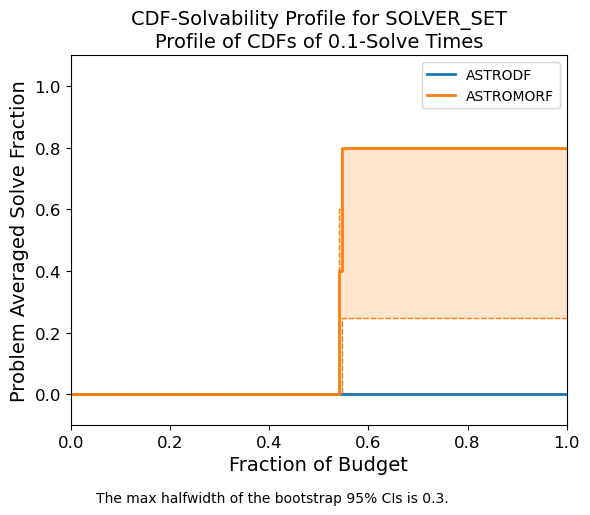

In [13]:
# Produce basic plots.

from simopt.experiment_base import PlotType, plot_solvability_profiles

print("Plotting results...")

def _print_path(plot_path: list[Path]) -> Path:
    print(f"Plot saved to {plot_path!s}")
    return plot_path[0]



group_plot = _print_path(
    plot_solvability_profiles(
        experiments=mymetaexperiment.experiments, plot_type=PlotType.CDF_SOLVABILITY, solve_tol=0.1
    )
)


print("Plotting complete!")

Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-24_03-56-44/plots/SOLVER_SET_DYNAMNEWS-1_mean_prog_curve_unnorm.png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-24_03-56-44/plots/SOLVER_SET_DYNAMNEWS-1_mean_prog_curve_unnorm (1).png')]


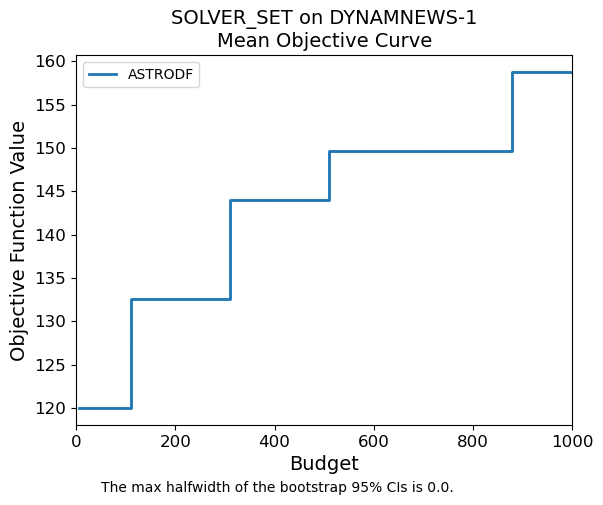

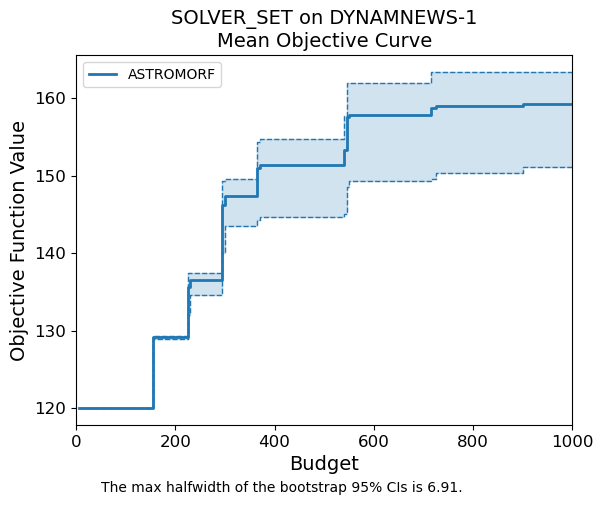

In [14]:
#plot individual plots 
from simopt.experiment_base import plot_progress_curves

ind_plots = []
no_probs = len(problem_abbr_names)
for idx in range(len(data_list)//2):
    # _print_path(
    # plot_progress_curves(
    #     experiments=[myexperiment], plot_type=PlotType.ALL, normalize=False
    #     )
    # )
    #For astrodf
    ind_plot_astrodf = _print_path(
        plot_progress_curves(
            experiments=[data_list[idx]], plot_type=PlotType.MEAN, normalize=False
        )
    )
    ind_plots.append(ind_plot_astrodf)

    ind_plot_astromorf = _print_path(
        plot_progress_curves(
            experiments=[data_list[no_probs + idx]], plot_type=PlotType.MEAN, normalize=False
        )
    )
    ind_plots.append(ind_plot_astromorf)

In [15]:
# #show plots
# from IPython.display import Image, display
# from pathlib import Path

# plots = ind_plots 

# no_of_prolems = len(problem_abbr_names)


# for i in range(len(plots)) :
#     display(Image(filename=str(plots[i])))
# # Example POSIX path
# # for i in range(no_of_prolems) :
# #     # Display the image
# #     other_solver_same_problem_index = i + no_of_prolems if i < no_of_prolems else i - no_of_prolems
# #     display(Image(filename=str(ind_plots[i])))
# #     #display the same p
# #     display(Image(filename=str(ind_plots[other_solver_same_problem_index])))

# #Display solvability profile
# display(Image(filename=str(group_plot)))

